# Quelques éléments pour comprendre les enjeux du NLP

Lino Galiana  
2023-12-20

Cette partie est une introduction
à la question du nettoyage de données textuelles.
Il s’agit de montrer la logique, quelques exemples
avec `Python` <i class="fab fa-python"></i>
et s’amuser avec comme base d’exemple un livre formidable 📖 :
[*Le Comte de Monte Cristo*](https://fr.wikipedia.org/wiki/Le_Comte_de_Monte-Cristo).

L’objectif est de découvrir les principaux enjeux du nettoyage de données en NLP
et les enjeux de l’analyse de fréquence.

## Base d’exemple

La base d’exemple est le *Comte de Monte Cristo* d’Alexandre Dumas.
Il est disponible
gratuitement sur le site
[Project Gutemberg](http://www.gutenberg.org/ebooks/author/492) comme des milliers
d’autres livres du domaine public.

La manière la plus simple de le récupérer
est de télécharger avec le *package* `Request` le fichier texte et le retravailler
légèrement pour ne conserver que le corpus du livre :

In [1]:
from urllib import request

url = "https://www.gutenberg.org/files/17989/17989-0.txt"
response = request.urlopen(url)
raw = response.read().decode('utf8')

dumas = raw.split("*** START OF THE PROJECT GUTENBERG EBOOK LE COMTE DE MONTE-CRISTO, TOME I ***")[1].split("*** END OF THE PROJECT GUTENBERG EBOOK LE COMTE DE MONTE-CRISTO, TOME I ***")[0]

import re

def clean_text(text):
    text = text.lower() # mettre les mots en minuscule
    text = " ".join(text.split())
    return text

dumas = clean_text(dumas)

dumas[10000:10500]

" mes yeux. --vous avez donc vu l'empereur aussi? --il est entré chez le maréchal pendant que j'y étais. --et vous lui avez parlé? --c'est-à-dire que c'est lui qui m'a parlé, monsieur, dit dantès en souriant. --et que vous a-t-il dit? --il m'a fait des questions sur le bâtiment, sur l'époque de son départ pour marseille, sur la route qu'il avait suivie et sur la cargaison qu'il portait. je crois que s'il eût été vide, et que j'en eusse été le maître, son intention eût été de l'acheter; mais je lu"

## La particularité des données textuelles

### Objectif

Le *natural language processing* (NLP) ou
*traitement automatisé du langage* (TAL) en Français,
vise à extraire de l’information de textes à partir d’une analyse statistique du contenu.
Cette définition permet d’inclure de nombreux champs d’applications au sein
du NLP (traduction, analyse de sentiment, recommandation, surveillance, etc. ).

Cette approche implique de transformer un texte, qui est une information compréhensible par un humain, en un nombre, information appropriée pour un ordinateur dans le cadre d’une approche statistique ou algorithmique.

Transformer une information textuelle en valeurs numériques propres à une analyse statistique n’est pas une tâche évidente. Les données textuelles sont **non structurées** puisque l’information cherchée, qui est propre à chaque analyse, est perdue au milieu d’une grande masse d’informations qui doit, de plus, être interprétée dans un certain contexte (un même mot ou une phrase n’ayant pas la même signification selon le contexte).

Si cette tâche n’était pas assez difficile comme ça, on peut ajouter d’autres difficultés propres à l’analyse textuelle car ces données sont :

-   **bruitées** : ortographe, fautes de frappe…
-   **changeantes** : la langue évolue avec de nouveaux mots, sens…
-   **complexes** : structures variables, accords…
-   **ambiguës** : synonymie, polysémie, sens caché…
-   **propres à chaque langue** : il n’existe pas de règle de passage unique entre deux langues
-   de **grande dimension** : des combinaisons infinies de séquences de mots

### Méthode

L’analyse textuelle vise à transformer le texte en données
numériques manipulables. Pour cela il est nécessaire de se fixer
une unité sémantique minimale.
Cette unité textuelle peut être le mot ou encore une séquence de *n*
mots (un *n-gramme*) ou encore une chaîne de caractères (e.g. la
ponctuation peut être signifiante). On parle de **token**.

On peut ensuite utiliser diverses techniques (*clustering*,
classification supervisée) suivant l’objectif poursuivi pour exploiter
l’information transformée. Mais les étapes de nettoyage de texte sont indispensables.
Sinon un algorithme sera incapable de détecter une information pertinente dans l’infini des possibles.

## Nettoyer un texte

Les *wordclouds* sont des représentations graphiques assez pratiques pour visualiser
les mots les plus fréquents, lorsqu’elles ne sont pas utilisées à tort et à travers.
Les *wordclouds* sont très simples à implémenter en `Python`
avec le module `Wordcloud`. Quelques paramètres de mise en forme
permettent même d’ajuster la forme du nuage à
une image :

In [2]:
import wordcloud
import numpy as np
import io
import requests
import PIL
import matplotlib.pyplot as plt

img = "https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/book.png"
book_mask = np.array(PIL.Image.open(io.BytesIO(requests.get(img).content)))

def make_wordcloud(corpus):
    wc = wordcloud.WordCloud(background_color="white", max_words=2000, mask=book_mask, contour_width=3, contour_color='steelblue')
    wc.generate(corpus)
    return wc

wordcloud_dumas = make_wordcloud(dumas)

(-0.5, 1429.5, 783.5, -0.5)

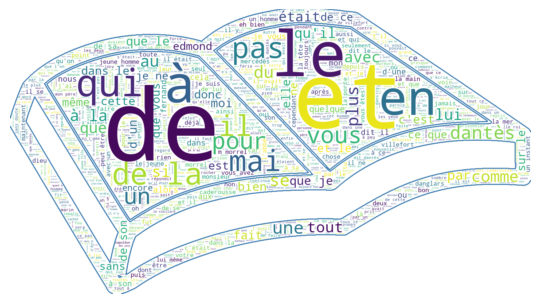

In [3]:
plt.imshow(wordcloud_dumas, interpolation='bilinear')
plt.axis("off")

Cela montre clairement qu’il est nécessaire de nettoyer notre texte. Le nom
du personnage principal, Dantès, est ainsi masqué par un certain nombre
d’articles ou mots de liaison qui perturbent l’analyse. Ces mots sont des
*stop words*.

La librairie `NLTK` (*Natural Language ToolKit*), librairie
de référence dans le domaine du NLP, permet de facilement retirer ces
*stop words* (cela pourrait également être fait avec
la librairie plus récente, `spaCy`). Avant cela, il est nécessaire
de transformer notre texte en le découpant par unités fondamentales (les *tokens*).

Les exemples suivants, extraits de Galiana and Castillo (2022), montrent l’intérêt du
nettoyage de textes lorsqu’on désire comparer des corpus
entre eux. En l’occurrence, il s’agit de comparer un corpus de
noms de produits dans des collectes automatisées de produits
de supermarché (*scanner-data*) avec des noms de produits
dans les données de l’`OpenFoodFacts`, une base de données
contributive. Sans nettoyage, le bruit l’emporte sur le signal
et il est impossible de déceler des similarités entre les jeux
de données. Le nettoyage permet d’harmoniser
un peu ces jeux de données pour avoir une chance d’être en
mesure de les comparer.

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr class="odd">
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/wordcloud_openfood_start.png" alt="OpenFoodFacts avant nettoyage" /></p>
</div></td>
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/wordcloud_relevanc_start.png" alt="Scanner-data avant nettoyage" /></p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr class="odd">
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/wordcloud_openfood_clean.png" alt="OpenFoodFacts après nettoyage" /></p>
</div></td>
<td style="text-align: center;"><div width="50.0%" data-layout-align="center">
<p><img src="https://minio.lab.sspcloud.fr/lgaliana/generative-art/pythonds/wordcloud_relevanc_clean.png" alt="Scanner-data après nettoyage" /></p>
</div></td>
</tr>
</tbody>
</table>

### Tokenisation

<div class="alert alert-warning" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #ffc10780;">
<h3 class="alert-heading"><i class="fa fa-lightbulb-o"></i> Hint</h3>

Lors de la première utilisation de `NLTK`, il est nécessaire de télécharger
quelques éléments nécessaires à la tokenisation, notamment la ponctuation.
Pour cela, il est recommandé d’utiliser la commande suivante :

``` python
import nltk
nltk.download('punkt')
```

</div>

In [4]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /github/home/nltk_data...
[nltk_data]   Package punkt is already up-to-date!

True

La tokenisation consiste à découper un texte en morceaux. Ces morceaux
pourraient être des phrases, des chapitres, des n-grammes ou des mots. C’est
cette dernière option que l’on va choisir, plus simple pour retirer les
*stop words* :

In [5]:
import nltk

words = nltk.word_tokenize(dumas, language='french')
words[1030:1050]

['que',
 'voulez-vous',
 ',',
 'monsieur',
 'edmond',
 ',',
 'reprit',
 "l'armateur",
 'qui',
 'paraissait',
 'se',
 'consoler',
 'de',
 'plus',
 'en',
 'plus',
 ',',
 'nous',
 'sommes',
 'tous']

On remarque que les mots avec apostrophes sont liés en un seul, ce qui est
peut-être faux sur le plan de la grammaire mais peu avoir un sens pour une
analyse statistique. Il reste des signes de ponctuation qu’on peut éliminer
avec la méthode `isalpha`:

In [6]:
words = [word for word in words if word.isalpha()]
words[1030:1050]

['assez',
 'sombre',
 'obséquieux',
 'envers',
 'ses',
 'supérieurs',
 'insolent',
 'envers',
 'ses',
 'subordonnés',
 'aussi',
 'outre',
 'son',
 'titre',
 'comptable',
 'qui',
 'est',
 'toujours',
 'un',
 'motif']

### Retirer les stop words

Le jeu de données est maintenant propre. On peut désormais retirer les
mots qui n’apportent pas de sens et servent seulement à faire le
lien entre deux prépositions. On appelle ces mots des
*stop words* dans le domaine du NLP.

<div class="alert alert-warning" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #ffc10780;">
<h3 class="alert-heading"><i class="fa fa-lightbulb-o"></i> Hint</h3>

Lors de la première utilisation de `NLTK`, il est nécessaire de télécharger
les *stop words*.

``` python
import nltk
nltk.download('stopwords')
```

</div>

Comme indiqué ci-dessus, pour télécharger
le corpus de *stop words*<a name="cite_ref-2"></a>[<sup>\[2\]</sup>](#cite_note-2), il est
nécessaire d’exécuter la ligne de
commande suivante :

In [7]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /github/home/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!

True

Le corpus de *stop words* de `NLTK`
est relativement limité. Il est recommandé
de privilégier celui de `SpaCy`, plus
complet, pour éliminer plus de mots
valises.

In [8]:
from nltk.corpus import stopwords
print(stopwords.words("french"))

stop_words = set(stopwords.words('french'))


words = [w for w in words if not w in stop_words]
print(words[1030:1050])

['au', 'aux', 'avec', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'elle', 'en', 'et', 'eux', 'il', 'ils', 'je', 'la', 'le', 'les', 'leur', 'lui', 'ma', 'mais', 'me', 'même', 'mes', 'moi', 'mon', 'ne', 'nos', 'notre', 'nous', 'on', 'ou', 'par', 'pas', 'pour', 'qu', 'que', 'qui', 'sa', 'se', 'ses', 'son', 'sur', 'ta', 'te', 'tes', 'toi', 'ton', 'tu', 'un', 'une', 'vos', 'votre', 'vous', 'c', 'd', 'j', 'l', 'à', 'm', 'n', 's', 't', 'y', 'été', 'étée', 'étées', 'étés', 'étant', 'étante', 'étants', 'étantes', 'suis', 'es', 'est', 'sommes', 'êtes', 'sont', 'serai', 'seras', 'sera', 'serons', 'serez', 'seront', 'serais', 'serait', 'serions', 'seriez', 'seraient', 'étais', 'était', 'étions', 'étiez', 'étaient', 'fus', 'fut', 'fûmes', 'fûtes', 'furent', 'sois', 'soit', 'soyons', 'soyez', 'soient', 'fusse', 'fusses', 'fût', 'fussions', 'fussiez', 'fussent', 'ayant', 'ayante', 'ayantes', 'ayants', 'eu', 'eue', 'eues', 'eus', 'ai', 'as', 'avons', 'avez', 'ont', 'aurai', 'auras', 'aura', 'aurons', 'aur

Ces retraitements commencent à porter leurs fruits puisque des mots ayant plus
de sens commencent à se dégager, notamment les noms des personnages
(Fernand, Mercédès, Villefort, etc.)

(-0.5, 1429.5, 783.5, -0.5)

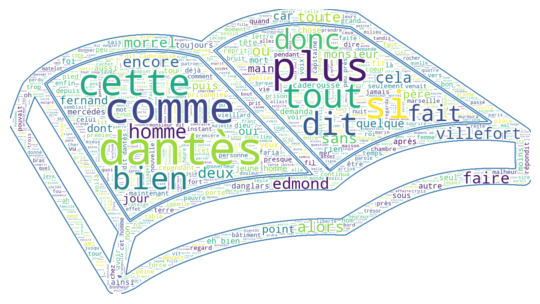

In [9]:
wc = make_wordcloud(' '.join(words))

fig = plt.figure()

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")

### *Stemming*

Pour réduire la complexité d’un texte, on peut tirer partie de
*“classes d’équivalence”* : on peut
considérer que différentes formes d’un même mot (pluriel,
singulier, conjugaison) sont équivalentes et les remplacer par une
même forme dite canonique. Il existe deux approches dans le domaine :

-   la **lemmatisation** qui requiert la connaissance des statuts
    grammaticaux (exemple : chevaux devient cheval)
-   la **racinisation** (*stemming*) plus fruste mais plus rapide, notamment
    en présence de fautes d’orthographes. Dans ce cas, chevaux peut devenir chev
    mais être ainsi confondu avec chevet ou cheveux

La racinisation est plus simple à mettre en oeuvre car elle peut s’appuyer sur
des règles simples pour extraire la racine d’un mot.

Pour réduire un mot dans sa forme “racine”, c’est-à-dire en s’abstrayant des
conjugaisons ou variations comme les pluriels, on applique une méthode de
*stemming*. Le but du *stemming* est de regrouper de
nombreuses variantes d’un mot comme un seul et même mot.
Par exemple, une fois que l’on applique un stemming, “chats” et “chat”
deviennent un même mot.

Cette approche a l’avantage de réduire la taille du vocabulaire à maîtriser
pour l’ordinateur et le modélisateur. Il existe plusieurs algorithmes de
*stemming*, notamment le *Porter Stemming Algorithm* ou le
*Snowball Stemming Algorithm*. Nous pouvons utiliser ce dernier en Français :

In [10]:
from nltk.stem.snowball import SnowballStemmer
stemmer = SnowballStemmer(language='french')

stemmed = [stemmer.stem(word) for word in words]
print(stemmed[1030:1050])

['celui', 'dantes', 'a', 'dépos', 'pass', 'comment', 'paquet', 'dépos', 'danglar', 'roug', 'pass', 'dev', 'port', 'capitain', 'entrouvert', 'vu', 'remettr', 'paquet', 'cet', 'lettr']

A ce niveau, les mots commencent à être moins intelligibles par un humain.
La machine prendra le relais, on lui a préparé le travail.

<div class="alert alert-info" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #007bff80;">
<h3 class="alert-heading"><i class="fa fa-comment"></i> Note</h3>

Il existe aussi le *stemmer* suivant :

``` python
from nltk.stem.snowball import FrenchStemmer
stemmer = FrenchStemmer()
```

</div>

## Reconnaissance des entités nommées

Cette étape n’est pas une étape de préparation mais illustre la capacité
des librairies `Python` a extraire du sens d’un texte. La librairie
`spaCy` permet de faire de la reconnaissance d’entités nommées
(*named entity recognition*, NER), ce qui peut
être pratique pour extraire rapidement certains personnages de notre oeuvre.

<div class="alert alert-info" role="alert" style="color: rgba(0,0,0,.8); background-color: white; margin-top: 1em; margin-bottom: 1em; margin:1.5625emauto; padding:0 .6rem .8rem!important;overflow:hidden; page-break-inside:avoid; border-radius:.25rem; box-shadow:0 .2rem .5rem rgba(0,0,0,.05),0 0 .05rem rgba(0,0,0,.1); transition:color .25s,background-color .25s,border-color .25s ; border-right: 1px solid #dee2e6 ; border-top: 1px solid #dee2e6 ; border-bottom: 1px solid #dee2e6 ; border-left:.2rem solid #007bff80;">
<h3 class="alert-heading"><i class="fa fa-comment"></i> La librairie <code>SpaCy</code></h3>

`NTLK` est la librairie historique d’analyse textuelle en `Python`. Elle existe
depuis les années 1990. L’utilisation industrielle du NLP dans le monde
de la *data science* est néanmoins plus récente et doit beaucoup à la collecte
accrue de données non structurées par les réseaux sociaux. Cela a amené à
un renouvellement du champ du NLP, tant dans le monde de la recherche que dans
sa mise en application dans l’industrie de la donnée.

Le *package* [`spaCy`](https://spacy.io/) est l’un des packages qui a permis
cette industrialisation des méthodes de NLP. Conçu autour du concept
de *pipelines* de données, il est beaucoup plus pratique à mettre en oeuvre
pour une chaîne de traitement de données textuelles mettant en oeuvre
plusieurs étapes de transformation des données.

</div>

Voici un exemple de reconnaissance d’entités nommées
sur les premières phrases de l’ouvrage :

In [11]:
#!pip install deplacy
!python -m spacy download fr_core_news_sm
import spacy
import spacy
from spacy import displacy

nlp=spacy.load("fr_core_news_sm")
doc = nlp(dumas[15000:17000])
displacy.render(doc, style="ent", jupyter=True)

2023-12-20 20:43:44.701652: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/16.3 MB ? eta -:--:--     ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/16.3 MB 67.4 MB/s eta 0:00:01     ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 7.1/16.3 MB 104.8 MB/s eta 0:00:01     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━ 12.3/16.3 MB 144.7 MB/s eta 0:00:01     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 16.3/16.3 MB 157.8 MB/s eta 0:00:01     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 93.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')

2023-12-20 20:43:51.799040: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.

us
 LOC 
 
 donne tout loisir de faire les vôtres. 
 
 avez
 LOC 
 
-vous besoin d'argent? --non, monsieur; j'ai tous mes appointements du voyage, c'est-à-dire près de trois mois de solde. --vous êtes un garçon rangé, 
 
 edmond.
 PER 
 
 --ajoutez que j'ai un père pauvre, monsieur morrel. --oui, oui, je sais que vous êtes un bon fils. allez donc voir votre père: j'ai un fils aussi, et j'en voudrais fort à celui qui, après un voyage de trois mois, le retiendrait loin de moi. --alors, vous permettez? dit le jeune homme en saluant. --oui, si vous n'avez rien de plus à me dire. 
 
 --non
 MISC 
 
. --le capitaine leclère ne vous a pas, en mourant, donné une lettre pour moi? --il lui eût été impossible d'écrire, monsieur; mais cela me rappelle que j'aurai un congé de quinze jours à vous demander. --pour vous marier? --d'abord; puis pour aller à 
 
 paris
 LOC 
 
. --bon, bon! vous prendrez le temps que vous voudrez, dantès; le temps de décharger le bâtiment nous prendra bien six semaines, et nous ne nous remettrons guère en mer avant trois mois.... seulement, dans trois mois, il faudra que vous soyez là. le _pharaon_, continua l'armateur en frappant sur l'épaule du jeune marin, ne pourrait pas repartir sans son capitaine. --sans son capitaine! s'écria dantès les yeux brillants de joie; faites bien attention à ce que vous dites là, monsieur, car vous venez de répondre aux plus secrètes espérances de mon coeur. votre intention serait-elle de me nommer capitaine du _pharaon_? --si j'étais seul, je vous tendrais la main, mon cher 
 
 dantès
 LOC 
 
, et je vous dirais: «c'est fait.» mais j'ai un associé, et vous savez le proverbe italien: _che a compagne a padrone_. mais la moitié de la 
 
 besogne
 LOC 
 
 est faite au moins, puisque sur deux voix vous en avez déjà une. rapportez-vous-en à moi pour avoir l'autre, et je ferai de mon mieux. 
 
 --oh!
 MISC 
 
 monsieur morrel, s'écria le jeune marin, saisissant, les larmes aux yeux, les mains de l'armateur; monsieur morrel, je vous remercie, au nom de mon père et de mercédès. 
 
 --c'
 PER 
 
est bien, c'est bien, edmond, il y a un dieu

La reconnaissance d’entités nommées disponible
par défaut est souvent décevante ; il est
souvent nécessaire d’enrichir les règles par défaut
par des règles *ad hoc*, propres à chaque corpus.

## Représentation d’un texte sous forme vectorielle

Une fois nettoyé, le texte est plus propice à une représentation vectorielle.
En fait, implicitement, on a depuis le début adopté une démarche *bag of words*.
Il s’agit d’une représentation, sans souci de contexte (ordre des mots, contexte d’utilisation),
où chaque *token* représente un élément dans un vocabulaire de taille $|V|$.
On peut ainsi avoir une représentation matricielle des occurrences de
chaque *token* dans plusieurs documents (par exemple plusieurs livres,
chapitres, etc.) pour par exemple en déduire une forme de similarité.

Afin de réduire la dimension de la matrice *bag of words*,
on peut s’appuyer sur des pondérations.
On élimine ainsi certains mots très fréquents ou au contraire très rares.
La pondération la plus simple est basée sur la fréquence des mots dans le document.
C’est l’objet de la métrique **tf-idf** (term frequency - inverse document frequency)
abordée dans un prochain chapitre.

## Références

Galiana, Lino, and Milena Suarez Castillo. 2022. “Fuzzy Matching on Big-Data an Illustration with Scanner Data and Crowd-Sourced Nutritional Data.”